## R Problem Statement 7
Name: Aditi Gawari

Roll no: 23102A0025

###Problem Statement:

An e-commerce company wants to better understand its customers
and improve its marketing decisions.

Using historical online retail transaction data, we will:

1. Preprocess the transaction data
2. Perform customer-level feature engineering
3. Calculate RFM features
4. Apply K-Means clustering
5. Determine optimal clusters using Elbow Method
6. Apply Hierarchical Clustering
7. Evaluate clustering using Silhouette Score
8. Apply PCA for dimensionality reduction
9. Profile customer segments
10. Identify high-value customers
11. Build Random Forest and SVM models
12. Evaluate models using:
       - Accuracy
       - Precision
       - Recall
       - F1-Score
       - ROC-AUC
       - Confusion Matrix
13. Analyze feature importance
14. Create an interactive 3D Plotly visualization
15. Provide marketing recommendations


In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

pd.set_option("display.max_columns", None)

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [3]:
file_name = list(uploaded.keys())[0]

print("Uploaded file:", file_name)

Uploaded file: Online Retail.xlsx


In [4]:
df = pd.read_excel(file_name)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape:
(541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

First 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_summary

,Missing Values,Percentage
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


In [9]:
print("Rows before removing missing CustomerID:", len(df))

df = df.dropna(subset=["CustomerID"])

print("Rows after removing missing CustomerID:", len(df))

Rows before removing missing CustomerID: 541909
Rows after removing missing CustomerID: 406829


In [10]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [11]:
cancelled = df["InvoiceNo"].astype(str).str.startswith("C")

print("Number of cancelled transactions:", cancelled.sum())

Number of cancelled transactions: 8905


In [12]:
df = df[
    ~df["InvoiceNo"].astype(str).str.startswith("C")
].copy()

print("Dataset shape after removing cancellations:")
print(df.shape)

Dataset shape after removing cancellations:
(397924, 8)


In [13]:
df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

print("Dataset shape after removing invalid transactions:")
print(df.shape)

Dataset shape after removing invalid transactions:
(397884, 8)


In [14]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

df["InvoiceDate"].head()

,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00


In [15]:
df["TotalPrice"] = (
    df["Quantity"] * df["UnitPrice"]
)

df[
    ["Quantity", "UnitPrice", "TotalPrice"]
].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


Number of unique customers

In [16]:
print(
    "Unique Customers:",
    df["CustomerID"].nunique()
)

Unique Customers: 4338


Number of unique products

In [17]:
print(
    "Unique Products:",
    df["StockCode"].nunique()
)

Unique Products: 3665


Number of Countries

In [18]:
print(
    "Number of Countries:",
    df["Country"].nunique()
)

Number of Countries: 37


Top Countries

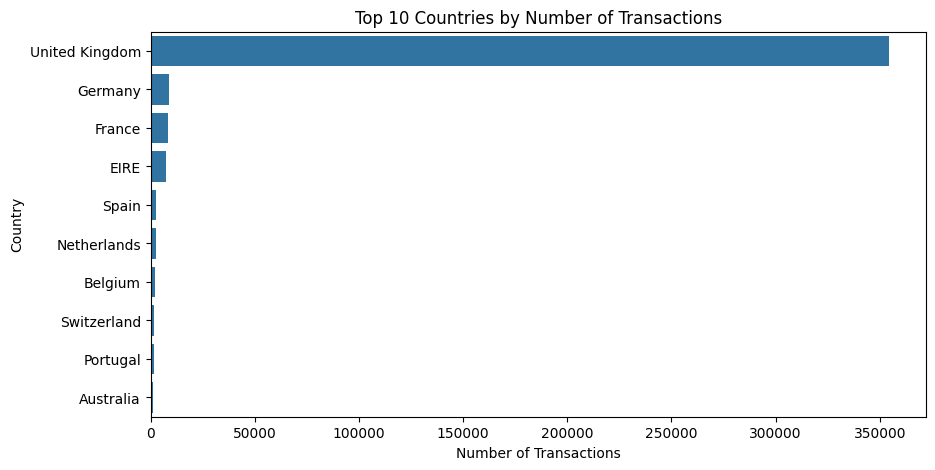

In [19]:
country_counts = (
    df["Country"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.show()

RFM Feature Engineering

In [20]:
reference_date = (
    df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


In [21]:
customer_rfm = df.groupby("CustomerID").agg({

    "InvoiceDate": lambda x:
        (reference_date - x.max()).days,

    "InvoiceNo": "nunique",

    "TotalPrice": "sum"
})

customer_rfm.rename(
    columns={
        "InvoiceDate": "Recency",
        "InvoiceNo": "Frequency",
        "TotalPrice": "Monetary"
    },
    inplace=True
)

customer_rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [22]:
avg_transaction = (
    df.groupby("CustomerID")["TotalPrice"]
    .mean()
    .rename("AvgTransactionValue")
)

In [26]:
total_quantity = (
    df.groupby("CustomerID")["Quantity"]
    .sum()
    .rename("TotalQuantity")
)

In [27]:
customer_data = pd.concat(
    [
        customer_rfm,
        avg_transaction,
        total_quantity
    ],
    axis=1
)

customer_data.head()

,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity
CustomerID,,,,,
12346.0,326,1,77183.60,77183.600000,74215
12347.0,2,7,4310.00,23.681319,2458
12348.0,75,4,1797.24,57.975484,2341
12349.0,19,1,1757.55,24.076027,631
12350.0,310,1,334.40,19.670588,197


Final Customer Dataset

In [28]:
print("Customer-level dataset shape:")
print(customer_data.shape)

display(customer_data.head(10))

Customer-level dataset shape:
(4338, 5)


,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity
CustomerID,,,,,
12346.0,326,1,77183.60,77183.600000,74215
12347.0,2,7,4310.00,23.681319,2458
12348.0,75,4,1797.24,57.975484,2341
12349.0,19,1,1757.55,24.076027,631
12350.0,310,1,334.40,19.670588,197
12352.0,36,8,2506.04,29.482824,536
12353.0,204,1,89.00,22.250000,20
12354.0,232,1,1079.40,18.610345,530
12355.0,214,1,459.40,35.338462,240


In [29]:
customer_data.describe()

,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460,68.350506,1191.289073
std,100.014169,7.697998,8989.230441,1467.918896,5046.081546
min,1.000000,1.000000,3.750000,2.101286,1.000000
25%,18.000000,1.000000,307.415000,12.365367,160.000000
50%,51.000000,2.000000,674.485000,17.723119,379.000000
75%,142.000000,5.000000,1661.740000,24.858417,992.750000
max,374.000000,209.000000,280206.020000,77183.600000,196915.000000


Visualize RFM Distributions

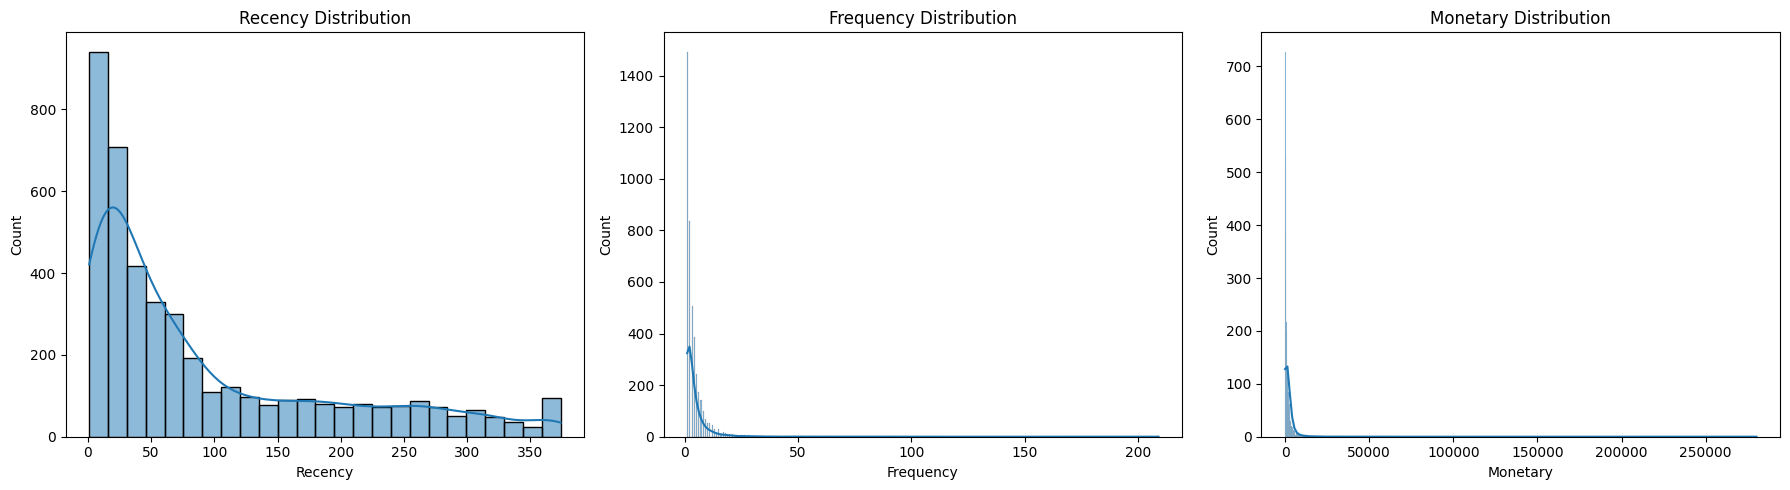

In [30]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

sns.histplot(
    customer_data["Recency"],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Recency Distribution")

sns.histplot(
    customer_data["Frequency"],
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Frequency Distribution")

sns.histplot(
    customer_data["Monetary"],
    kde=True,
    ax=axes[2]
)

axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

Outlier Treatment

In [31]:
def cap_outliers(series):

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return series.clip(
        lower_bound,
        upper_bound
    )

In [32]:
features_for_clustering = [
    "Recency",
    "Frequency",
    "Monetary",
    "AvgTransactionValue",
    "TotalQuantity"
]

for column in features_for_clustering:

    customer_data[column] = cap_outliers(
        customer_data[column]
    )

print("Outlier treatment completed.")

Outlier treatment completed.


In [33]:
customer_data[features_for_clustering].describe()

,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity
count,4338.000000,4338.00000,4338.000000,4338.000000,4338.000000
mean,91.447441,3.48663,1162.912410,20.056045,684.891194
std,97.199547,3.04011,1148.071634,11.643467,699.036420
min,1.000000,1.00000,3.750000,2.101286,1.000000
25%,18.000000,1.00000,307.415000,12.365367,160.000000
50%,51.000000,2.00000,674.485000,17.723119,379.000000
75%,142.000000,5.00000,1661.740000,24.858417,992.750000
max,328.000000,11.00000,3693.227500,43.597992,2241.875000


Feature Scaling

In [34]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    customer_data[features_for_clustering]
)

scaled_features = pd.DataFrame(
    scaled_features,
    columns=features_for_clustering,
    index=customer_data.index
)

scaled_features.head()

,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity
CustomerID,,,,,
12346.0,2.413382,-0.818035,2.204224,2.022135,2.227585
12347.0,-0.920352,1.155805,2.204224,0.311393,2.227585
12348.0,-0.169233,0.168885,0.552579,2.022135,2.227585
12349.0,-0.745433,-0.818035,0.518004,0.345296,-0.077102
12350.0,2.248753,-0.818035,-0.721739,-0.033109,-0.698029


In [35]:
scaled_features.mean()

,0
Recency,7.043185e-17
Frequency,1.637950e-18
Monetary,7.206980e-17
AvgTransactionValue,6.551800e-18
TotalQuantity,6.551800e-17


Elbow Method

In [36]:
inertia = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

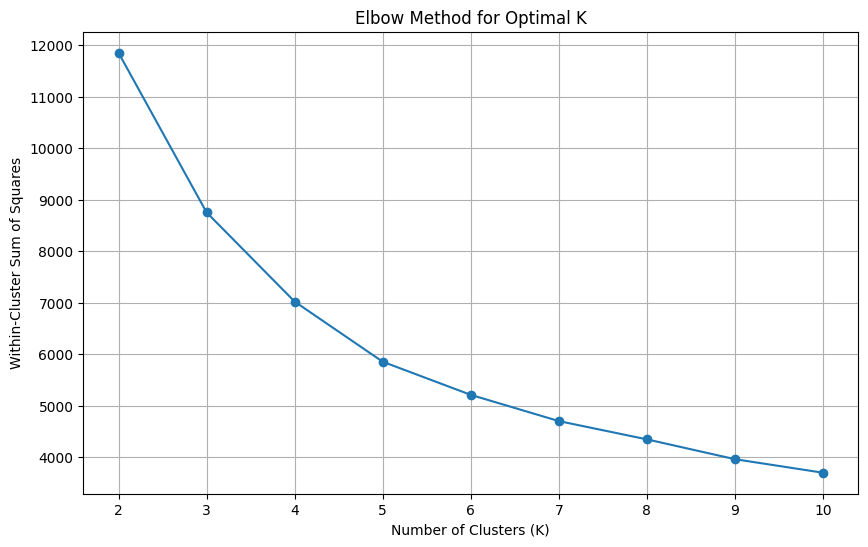

In [38]:
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares")

plt.xticks(K_range)

plt.grid(True)

plt.show()

k-means Clustering

In [50]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans.fit_predict(
    scaled_features
)

customer_data.head()

,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity,Cluster
CustomerID,,,,,,
12346.0,326,1,3693.2275,43.597992,2241.875,2
12347.0,2,7,3693.2275,23.681319,2241.875,1
12348.0,75,4,1797.2400,43.597992,2241.875,1
12349.0,19,1,1757.5500,24.076027,631.000,0
12350.0,310,1,334.4000,19.670588,197.000,3


In [51]:
cluster_sizes = (
    customer_data["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_sizes

,count
Cluster,
0,1968
1,914
2,593
3,863


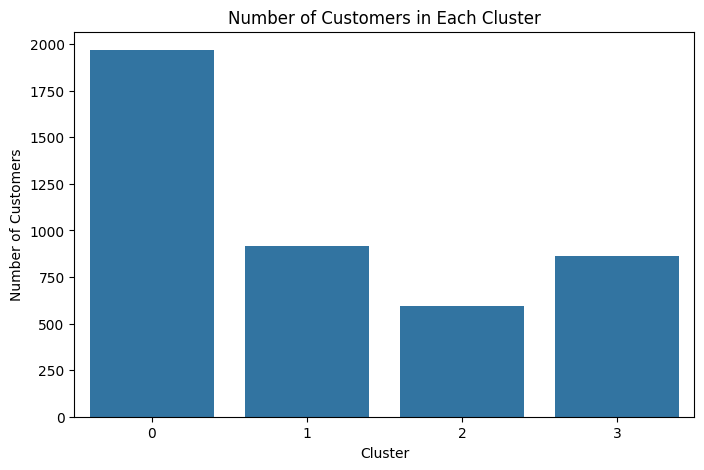

In [52]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_sizes.index,
    y=cluster_sizes.values
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [53]:
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=features_for_clustering
)

cluster_centers

,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity
0,-0.462449,-0.277710,-0.388808,-0.493771,-0.349293
1,-0.654182,1.519009,1.681521,0.301973,1.639581
2,0.227979,-0.427033,-0.275330,1.677710,-0.348201
3,1.592124,-0.680263,-0.703155,-0.348058,-0.698781


Silhouette Score

In [54]:
kmeans_silhouette = silhouette_score(
    scaled_features,
    customer_data["Cluster"]
)

print(
    "K-Means Silhouette Score:",
    round(kmeans_silhouette, 4)
)

K-Means Silhouette Score: 0.3782


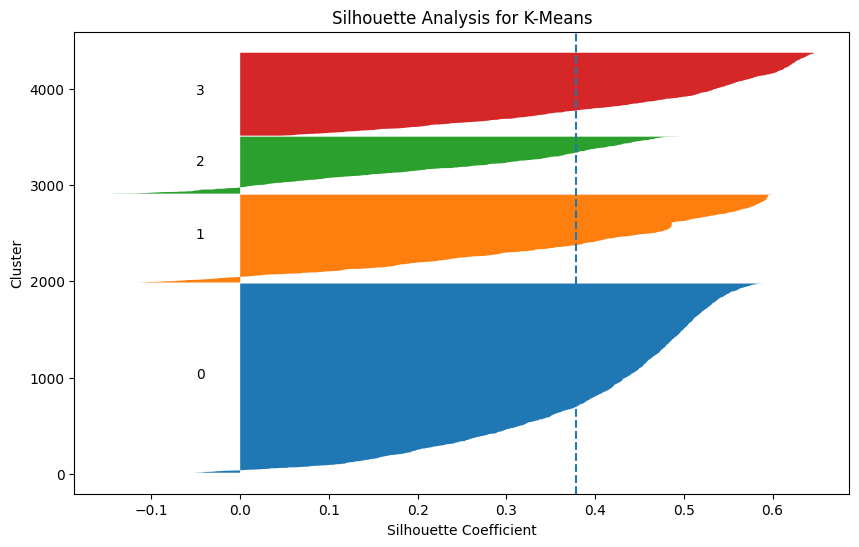

In [55]:
from sklearn.metrics import silhouette_samples

sample_silhouette_values = silhouette_samples(
    scaled_features,
    customer_data["Cluster"]
)

plt.figure(figsize=(10, 6))

y_lower = 10

for cluster in range(optimal_k):

    cluster_values = sample_silhouette_values[
        customer_data["Cluster"] == cluster
    ]

    cluster_values.sort()

    size_cluster = len(cluster_values)

    y_upper = y_lower + size_cluster

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_values
    )

    plt.text(
        -0.05,
        y_lower + 0.5 * size_cluster,
        str(cluster)
    )

    y_lower = y_upper + 10

plt.axvline(
    x=kmeans_silhouette,
    linestyle="--"
)

plt.title("Silhouette Analysis for K-Means")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")

plt.show()

Hierarchical Clustering

In [56]:
from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)

np.random.seed(42)

sample_size = min(
    1000,
    len(scaled_features)
)

sample_indices = np.random.choice(
    len(scaled_features),
    sample_size,
    replace=False
)

hierarchical_sample = scaled_features.iloc[
    sample_indices
]

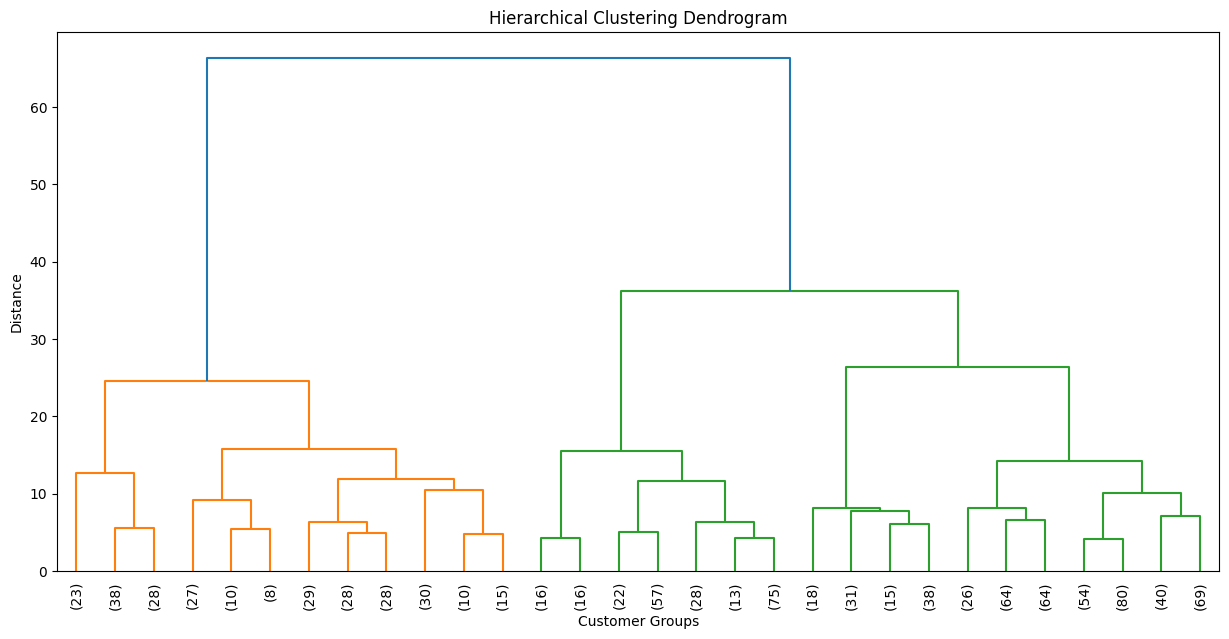

In [57]:
linked = linkage(
    hierarchical_sample,
    method="ward"
)

plt.figure(figsize=(15, 7))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel("Customer Groups")
plt.ylabel("Distance")

plt.show()

In [58]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(
    hierarchical_sample
)

print(
    "Hierarchical cluster counts:"
)

print(
    pd.Series(
        hierarchical_labels
    ).value_counts().sort_index()
)

Hierarchical cluster counts:
0    274
1    397
2    227
3    102
Name: count, dtype: int64


Hierarchical Silhouette Score

In [59]:
hierarchical_silhouette = silhouette_score(
    hierarchical_sample,
    hierarchical_labels
)

print(
    "Hierarchical Clustering Silhouette Score:",
    round(hierarchical_silhouette, 4)
)

Hierarchical Clustering Silhouette Score: 0.3314


Comparing Clustering Methods

In [60]:
clustering_comparison = pd.DataFrame({

    "Method": [
        "K-Means",
        "Hierarchical Clustering"
    ],

    "Silhouette Score": [
        kmeans_silhouette,
        hierarchical_silhouette
    ]
})

clustering_comparison

,Method,Silhouette Score
0,K-Means,0.378202
1,Hierarchical Clustering,0.331439


PCA

In [61]:
pca = PCA(
    n_components=3
)

pca_result = pca.fit_transform(
    scaled_features
)

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2", "PC3"]
)

pca_df["Cluster"] = (
    customer_data["Cluster"].values
)

pca_df.head()

,PC1,PC2,PC3,Cluster
0,1.463615,3.243053,1.939408,2
1,3.375696,0.067562,0.285427,1
2,1.932587,1.851569,-0.353787,1
3,0.114742,0.096479,-0.831318,0
4,-1.960605,0.944145,1.413849,3


Explained Variance

In [62]:
explained_variance = (
    pca.explained_variance_ratio_
)

print(
    "Explained Variance:"
)

for i, variance in enumerate(
    explained_variance,
    start=1
):

    print(
        f"PC{i}: {variance:.4f}"
    )

print(
    "\nTotal variance explained by 3 PCs:",
    round(explained_variance.sum(), 4)
)

Explained Variance:
PC1: 0.6002
PC2: 0.2091
PC3: 0.1330

Total variance explained by 3 PCs: 0.9423


PCA Variance Plot

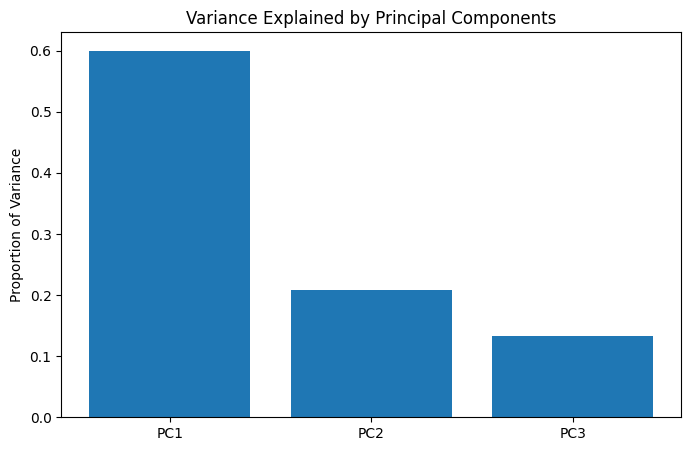

In [63]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["PC1", "PC2", "PC3"],
    explained_variance
)

plt.title(
    "Variance Explained by Principal Components"
)

plt.ylabel("Proportion of Variance")

plt.show()

2D PCA Visualization

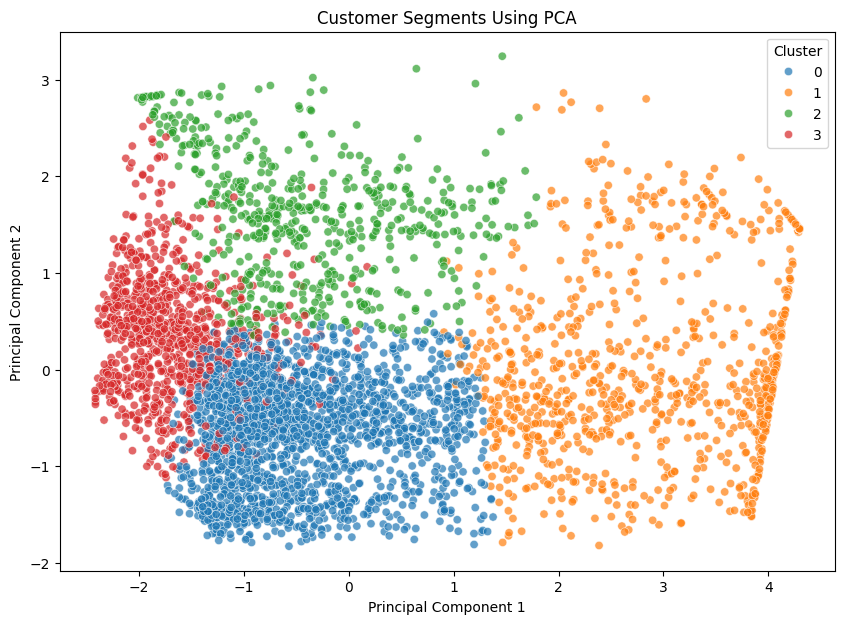

In [64]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.7
)

plt.title(
    "Customer Segments Using PCA"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    title="Cluster"
)

plt.show()

Customer Cluster Profiling

In [65]:
cluster_profile = (
    customer_data
    .groupby("Cluster")
    .agg(
        Customers=("Cluster", "count"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean"),
        AvgTransactionValue=(
            "AvgTransactionValue",
            "mean"
        ),
        AvgQuantity=(
            "TotalQuantity",
            "mean"
        )
    )
)

cluster_profile.round(2)

,Customers,AvgRecency,AvgFrequency,AvgMonetary,AvgTransactionValue,AvgQuantity
Cluster,,,,,,
0,1968,46.53,2.64,716.33,14.31,440.50
1,914,27.84,8.11,3091.15,23.55,1829.91
2,593,113.32,2.19,848.15,39.59,442.03
3,863,246.22,1.42,355.41,16.03,196.40


In [66]:
profile_features = [
    "AvgRecency",
    "AvgFrequency",
    "AvgMonetary",
    "AvgTransactionValue",
    "AvgQuantity"
]

profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(
        cluster_profile[profile_features]
    ),
    columns=profile_features,
    index=cluster_profile.index
)

profile_scaled.round(2)

,AvgRecency,AvgFrequency,AvgMonetary,AvgTransactionValue,AvgQuantity
Cluster,,,,,
0,-0.72,-0.36,-0.50,-0.91,-0.44
1,-0.94,1.71,1.71,0.02,1.71
2,0.06,-0.53,-0.38,1.62,-0.44
3,1.61,-0.82,-0.83,-0.73,-0.82


Visualize Cluster Profiles

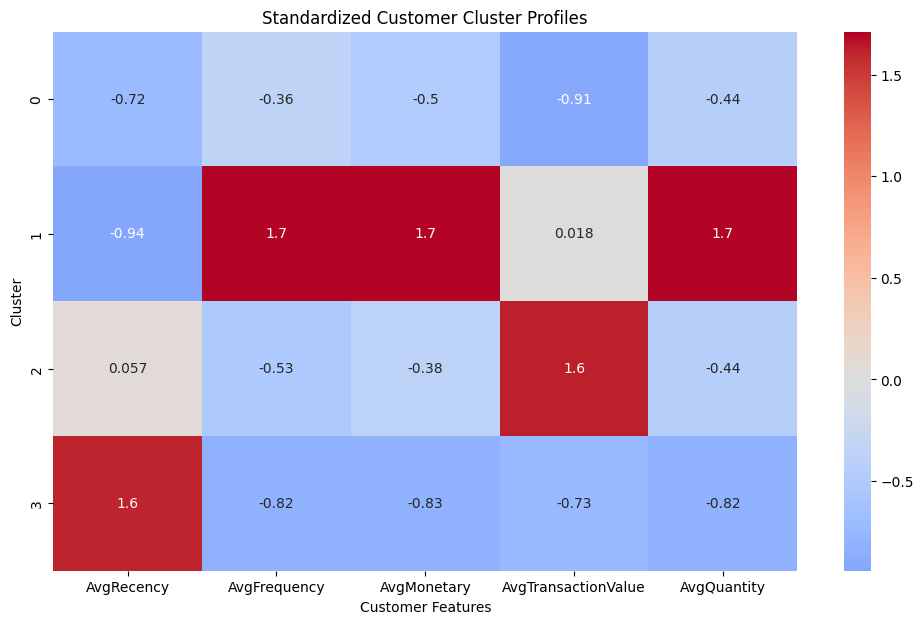

In [67]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    profile_scaled,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Standardized Customer Cluster Profiles"
)

plt.xlabel("Customer Features")
plt.ylabel("Cluster")

plt.show()

High Value Customers

In [68]:
high_value_cluster = (
    cluster_profile["AvgMonetary"]
    .idxmax()
)

print(
    "High-value customer cluster:",
    high_value_cluster
)

High-value customer cluster: 1


In [69]:
customer_data["HighValue"] = (
    customer_data["Cluster"]
    == high_value_cluster
).astype(int)

In [71]:
customer_data["HighValue"].value_counts()

,count
HighValue,
0,3424
1,914


Classification using Random Forest

In [72]:
classification_features = [
    "Recency",
    "Frequency",
    "AvgTransactionValue",
    "TotalQuantity"
]

X = customer_data[
    classification_features
]

y = customer_data[
    "HighValue"
]

In [73]:
print("Features:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features:
['Recency', 'Frequency', 'AvgTransactionValue', 'TotalQuantity']

Target distribution:
HighValue
0    3424
1     914
Name: count, dtype: int64


In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training samples:",
    X_train.shape[0]
)

print(
    "Testing samples:",
    X_test.shape[0]
)

Training samples: 3470
Testing samples: 868


In [75]:
classification_scaler = StandardScaler()

X_train_scaled = (
    classification_scaler
    .fit_transform(X_train)
)

X_test_scaled = (
    classification_scaler
    .transform(X_test)
)

In [76]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(
    X_train,
    y_train
)

print(
    "Random Forest model trained successfully."
)

Random Forest model trained successfully.


In [77]:
rf_predictions = rf_model.predict(
    X_test
)

rf_probabilities = rf_model.predict_proba(
    X_test
)[:, 1]

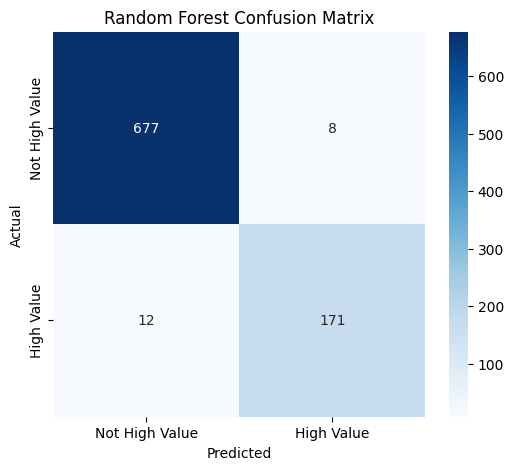

In [79]:
rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not High Value", "High Value"],
    yticklabels=["Not High Value", "High Value"]
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [80]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

Random Forest Performance
-------------------------
Accuracy : 0.977
Precision: 0.9553
Recall   : 0.9344
F1-Score : 0.9448
ROC-AUC  : 0.9955


In [81]:
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "Not High Value",
            "High Value"
        ]
    )
)

                precision    recall  f1-score   support

Not High Value       0.98      0.99      0.99       685
    High Value       0.96      0.93      0.94       183

      accuracy                           0.98       868
     macro avg       0.97      0.96      0.97       868
  weighted avg       0.98      0.98      0.98       868



In [82]:
feature_importance = pd.DataFrame({

    "Feature": classification_features,

    "Importance":
        rf_model.feature_importances_

}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,TotalQuantity,0.565761
1,Frequency,0.324062
0,Recency,0.073863
2,AvgTransactionValue,0.036314


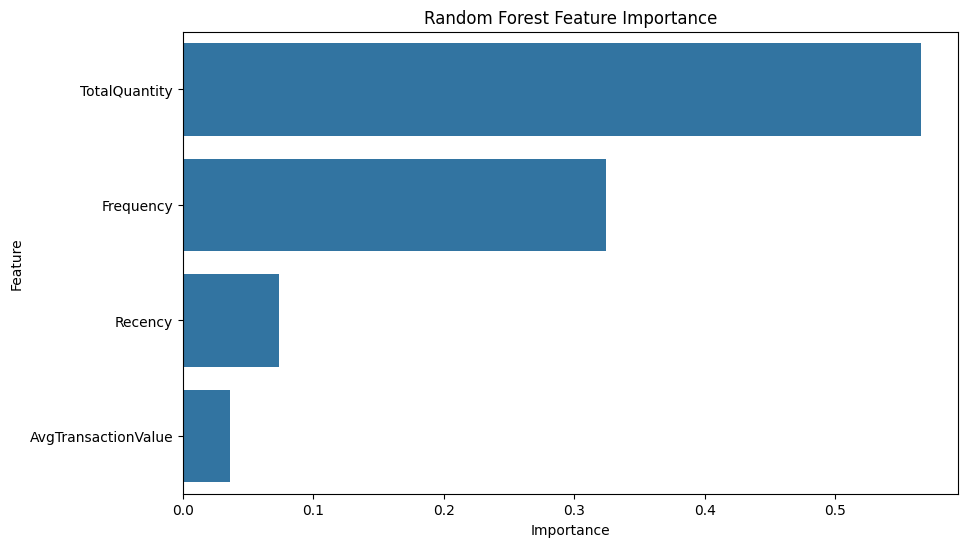

In [83]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

SVM Model

In [84]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42,
    class_weight="balanced"
)

svm_model.fit(
    X_train_scaled,
    y_train
)

print(
    "SVM model trained successfully."
)

SVM model trained successfully.


In [85]:
svm_predictions = svm_model.predict(
    X_test_scaled
)

svm_probabilities = svm_model.predict_proba(
    X_test_scaled
)[:, 1]

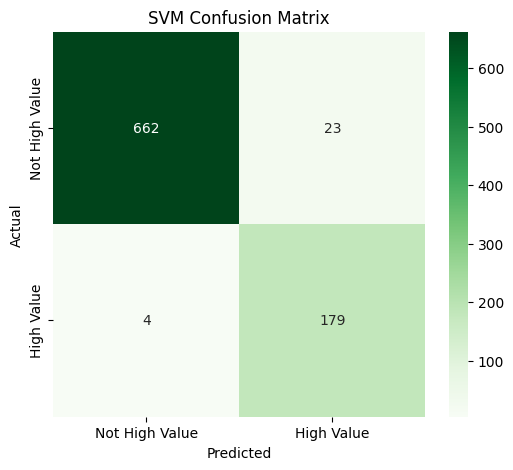

In [86]:
svm_cm = confusion_matrix(
    y_test,
    svm_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Not High Value", "High Value"],
    yticklabels=["Not High Value", "High Value"]
)

plt.title(
    "SVM Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [87]:
svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_precision = precision_score(
    y_test,
    svm_predictions,
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    svm_predictions,
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    svm_predictions,
    zero_division=0
)

svm_auc = roc_auc_score(
    y_test,
    svm_probabilities
)

print("SVM Performance")
print("----------------")
print("Accuracy :", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall   :", round(svm_recall, 4))
print("F1-Score :", round(svm_f1, 4))
print("ROC-AUC  :", round(svm_auc, 4))

SVM Performance
----------------
Accuracy : 0.9689
Precision: 0.8861
Recall   : 0.9781
F1-Score : 0.9299
ROC-AUC  : 0.9974


In [88]:
print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=[
            "Not High Value",
            "High Value"
        ]
    )
)

                precision    recall  f1-score   support

Not High Value       0.99      0.97      0.98       685
    High Value       0.89      0.98      0.93       183

      accuracy                           0.97       868
     macro avg       0.94      0.97      0.95       868
  weighted avg       0.97      0.97      0.97       868



Comparison of the models

In [89]:
model_comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "SVM"
    ],

    "Accuracy": [
        rf_accuracy,
        svm_accuracy
    ],

    "Precision": [
        rf_precision,
        svm_precision
    ],

    "Recall": [
        rf_recall,
        svm_recall
    ],

    "F1-Score": [
        rf_f1,
        svm_f1
    ],

    "ROC-AUC": [
        rf_auc,
        svm_auc
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9770,0.9553,0.9344,0.9448,0.9955
1,SVM,0.9689,0.8861,0.9781,0.9299,0.9974


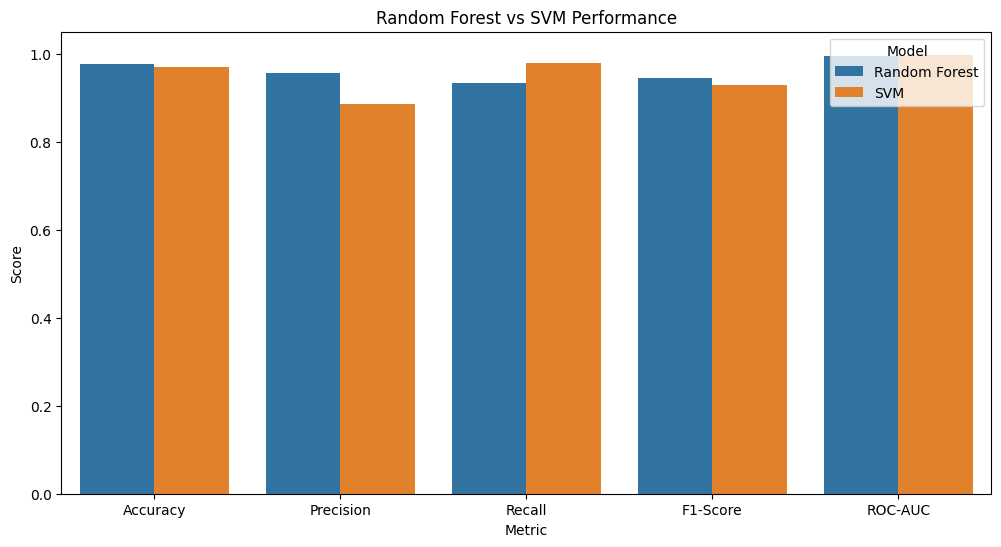

In [90]:
comparison_melted = model_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title(
    "Random Forest vs SVM Performance"
)

plt.ylim(0, 1.05)

plt.show()

ROC Curve

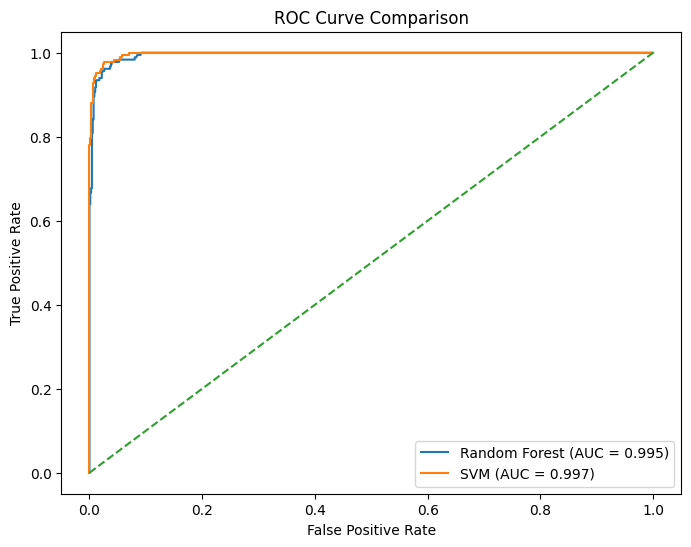

In [91]:
rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probabilities
)

svm_fpr, svm_tpr, _ = roc_curve(
    y_test,
    svm_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    svm_fpr,
    svm_tpr,
    label=f"SVM (AUC = {svm_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison"
)

plt.legend()

plt.show()

Interactive 3D PCA Visualization

In [92]:
fig = px.scatter_3d(
    pca_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Cluster",
    title="3D Visualization of Customer Segments",
    hover_data={
        "PC1": True,
        "PC2": True,
        "PC3": True,
        "Cluster": True
    }
)

fig.update_traces(
    marker=dict(
        size=4
    )
)

fig.show()

Final Cluster Profile

In [94]:
final_profile = (
    customer_data
    .groupby("Cluster")
    .agg(
        Number_of_Customers=("Cluster", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Avg_Transaction_Value=(
            "AvgTransactionValue",
            "mean"
        ),
        Avg_Quantity=(
            "TotalQuantity",
            "mean"
        )
    )
    .round(2)
)

final_profile

,Number_of_Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Transaction_Value,Avg_Quantity
Cluster,,,,,,
0,1968,46.53,2.64,716.33,14.31,440.50
1,914,27.84,8.11,3091.15,23.55,1829.91
2,593,113.32,2.19,848.15,39.59,442.03
3,863,246.22,1.42,355.41,16.03,196.40


In [95]:
for cluster in final_profile.index:

    print(
        f"\n========== Cluster {cluster} =========="
    )

    print(
        final_profile.loc[cluster]
    )


========== Cluster 0 ==========
Number_of_Customers      1968.00
Avg_Recency                46.53
Avg_Frequency               2.64
Avg_Monetary              716.33
Avg_Transaction_Value      14.31
Avg_Quantity              440.50
Name: 0, dtype: float64

========== Cluster 1 ==========
Number_of_Customers       914.00
Avg_Recency                27.84
Avg_Frequency               8.11
Avg_Monetary             3091.15
Avg_Transaction_Value      23.55
Avg_Quantity             1829.91
Name: 1, dtype: float64

========== Cluster 2 ==========
Number_of_Customers      593.00
Avg_Recency              113.32
Avg_Frequency              2.19
Avg_Monetary             848.15
Avg_Transaction_Value     39.59
Avg_Quantity             442.03
Name: 2, dtype: float64

========== Cluster 3 ==========
Number_of_Customers      863.00
Avg_Recency              246.22
Avg_Frequency              1.42
Avg_Monetary             355.41
Avg_Transaction_Value     16.03
Avg_Quantity             196.40
Name: 3, dtype: 

Marketing Recommendations

In [96]:
marketing_recommendations = pd.DataFrame({

    "Customer Segment": [
        "High-Value Customers",
        "Regular Customers",
        "New/Recent Customers",
        "At-Risk Customers"
    ],

    "Marketing Strategy": [
        "VIP rewards, loyalty programs, early access and personalized offers",

        "Cross-selling, product bundles and personalized recommendations",

        "Welcome campaigns, onboarding offers and incentives for repeat purchases",

        "Win-back campaigns, personalized discounts and re-engagement emails"
    ]
})

marketing_recommendations

,Customer Segment,Marketing Strategy
0,High-Value Customers,"VIP rewards, loyalty programs, early access an..."
1,Regular Customers,"Cross-selling, product bundles and personalize..."
2,New/Recent Customers,"Welcome campaigns, onboarding offers and incen..."
3,At-Risk Customers,"Win-back campaigns, personalized discounts and..."


In [97]:
print("=" * 60)
print("CUSTOMER SEGMENTATION RESULTS")
print("=" * 60)

print("\nNumber of Customers:",
      customer_data.shape[0])

print("\nOptimal Number of Clusters:",
      optimal_k)

print("\nK-Means Silhouette Score:",
      round(kmeans_silhouette, 4))

print("\nHierarchical Silhouette Score:",
      round(hierarchical_silhouette, 4))

print("\nHigh-Value Cluster:",
      high_value_cluster)

print("\nModel Performance:")
display(model_comparison.round(4))

CUSTOMER SEGMENTATION RESULTS

Number of Customers: 4338

Optimal Number of Clusters: 4

K-Means Silhouette Score: 0.3782

Hierarchical Silhouette Score: 0.3314

High-Value Cluster: 1

Model Performance:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9770,0.9553,0.9344,0.9448,0.9955
1,SVM,0.9689,0.8861,0.9781,0.9299,0.9974


### Interpretation of Results

#### 1. Data Preprocessing and Feature Engineering

The Online Retail dataset initially contained **541,909 transactions**. The data was preprocessed by handling missing Customer IDs, removing cancelled transactions and invalid transactions, and treating outliers. Customer-level features were then generated using Recency, Frequency, Monetary Value, Average Transaction Value, and Total Quantity. After preprocessing and aggregation, **4,338 unique customers** were available for analysis.

#### 2. K-Means Customer Segmentation

The Elbow Method indicated **4 clusters** as an appropriate choice for customer segmentation. K-Means was therefore applied with four clusters. The resulting clusters contained 1,968, 914, 593, and 863 customers respectively.

The cluster profiles show clear differences in customer purchasing behaviour:

* **Cluster 0:** 1,968 customers with relatively low recency (46.53 days), moderate frequency (2.64), and moderate monetary value (716.33).
* **Cluster 1:** 914 customers with the lowest recency (27.84 days), highest frequency (8.11), highest monetary value (3091.15), and highest quantity purchased (1829.91). This cluster was identified as the **high-value customer segment**.
* **Cluster 2:** 593 customers with higher recency (113.32 days), low frequency (2.19), but the highest average transaction value (39.59).
* **Cluster 3:** 863 customers with the highest recency (246.22 days), lowest frequency (1.42), and lowest monetary value (355.41), indicating relatively inactive or low-engagement customers.

Therefore, the clusters represent distinctly different purchasing behaviours and can be used to design customer-specific marketing strategies.

#### 3. Silhouette Score and Clustering Quality

The K-Means clustering produced a **Silhouette Score of 0.3782**, while Hierarchical Clustering produced a score of **0.3314**.

The positive scores indicate that the identified clusters have meaningful separation, although some overlap exists between customer groups. The K-Means result had the higher Silhouette Score in this experiment, indicating better separation according to this metric.

#### 4. PCA Analysis

PCA was used to reduce the dimensionality of the customer features while retaining the major patterns in the data. The first three principal components explained **94.23% of the total variance**, with PC1 explaining 60.02%, PC2 explaining 20.91%, and PC3 explaining 13.30%.

This indicates that the three-dimensional PCA representation preserves most of the information contained in the original customer features. The PCA visualizations therefore provide a useful representation of the separation between the identified customer segments.

#### 5. High-Value Customer Segment

Cluster **1** was identified as the high-value customer segment because it had the highest average monetary value of **3091.15**, together with the highest purchase frequency and total quantity.

These customers also had the lowest average recency of 27.84 days, indicating that they purchased relatively recently. This combination of high frequency, high spending, high quantity, and low recency makes Cluster 1 an important segment for targeted customer-retention and loyalty strategies.

#### 6. Random Forest and SVM Performance

Two supervised learning models, Random Forest and SVM, were developed to predict high-value customer membership.

The Random Forest model achieved:

* Accuracy: **97.70%**
* Precision: **95.53%**
* Recall: **93.44%**
* F1-Score: **94.48%**
* ROC-AUC: **99.55%**

The SVM model achieved:

* Accuracy: **96.89%**
* Precision: **88.61%**
* Recall: **97.81%**
* F1-Score: **92.99%**
* ROC-AUC: **99.74%**

Both models demonstrated strong predictive performance. The Random Forest produced higher accuracy, precision, and F1-score, while SVM achieved higher recall and a slightly higher ROC-AUC. This shows that both models were effective but exhibited different performance characteristics across the evaluation metrics.

#### 7. Feature Importance

The Random Forest feature importance analysis showed that **Total Quantity** was the most influential feature, with an importance of approximately **0.566**, followed by **Frequency** at approximately **0.324**. Recency contributed approximately 0.074, while Average Transaction Value had an importance of approximately 0.036.

This indicates that the quantity purchased and frequency of purchases were the strongest predictors of high-value customer membership in the developed model.

#### 8. Marketing Interpretation

The identified segments can support differentiated marketing strategies. The high-value Cluster 1 can be targeted with loyalty programs, personalized offers, exclusive products, and retention campaigns. Cluster 0 represents a relatively large group of moderately active customers who can be encouraged to increase their purchase frequency through cross-selling and personalized recommendations.

Cluster 2 contains customers with a relatively high average transaction value but lower purchase frequency, making them suitable for strategies aimed at increasing repeat purchases. Cluster 3 has the highest recency and lowest purchasing activity, making re-engagement and win-back campaigns appropriate for this segment.

### Conclusion

The experiment successfully applied an end-to-end machine learning workflow for customer segmentation and predictive analytics using the Online Retail dataset. After preprocessing the transaction data, customer-level RFM and purchasing features were generated for **4,338 customers**. K-Means clustering identified **four distinct customer segments**, while Hierarchical Clustering provided an additional comparison of the segmentation structure. The K-Means Silhouette Score was **0.3782**, compared with **0.3314** for Hierarchical Clustering.

PCA demonstrated that the first three components retained **94.23% of the total variance**, allowing the customer segments to be effectively visualized in a reduced-dimensional space. Cluster 1 was identified as the high-value segment because of its combination of high frequency, monetary value, quantity purchased, and recent purchasing activity.

For high-value customer prediction, both Random Forest and SVM achieved strong classification results, with ROC-AUC values above 0.99. The results demonstrate that machine learning can effectively identify different customer purchasing patterns and predict high-value customers. The resulting customer profiles can be used to develop targeted marketing strategies, improve customer retention, encourage repeat purchases, and support data-driven marketing decisions.
